# Analisi dei Risultati: Confronto tra MapReduce e Spark

Questo notebook analizza le prestazioni dei job implementati utilizzando MapReduce e Spark (Core e SQL API) per l'analisi del dataset delle auto usate. Confronteremo i tempi di esecuzione e le prestazioni al variare della dimensione dell'input e delle tecnologie utilizzate.

In [1]:
# Import delle librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

# Impostazioni per i grafici
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

## 1. Operazioni di Preparazione dei Dati

Prima di eseguire i job di analisi, sono state effettuate le seguenti operazioni di preparazione sui dati grezzi delle auto usate:

### Pulizia e Preprocessing
1. **Gestione dei valori mancanti**:
   - Rimozione di colonne con oltre il 70% di valori mancanti
   - Imputazione di valori mancanti con mediana (numerici) o moda (categorici)
   - Creazione di feature indicatrici per valori mancanti

2. **Trasformazione dei dati**:
   - Conversione di colonne testuali in numeriche (es. rimozione di unità di misura)
   - Estrazione di valori numerici da campi testuali (potenza, coppia, numero di posti, ecc.)
   - Parsing e normalizzazione di liste di opzioni

3. **Pulizia del testo**:
   - Pulizia delle descrizioni (rimozione di tag, caratteri speciali)
   - Tokenizzazione e rimozione delle stop words

4. **Derivazione di feature**:
   - Estrazione di informazioni temporali dalle date
   - Generazione di feature aggregate come il numero di opzioni

5. **Rimozione dei duplicati**:
   - Identificazione e rimozione di annunci duplicati basati sul VIN

### Campionamento
Per i benchmark sono stati creati campioni di diverse dimensioni dal dataset completo:
- 1% (circa 30,000 record)
- 5% (circa 150,000 record)
- 10% (circa 300,000 record)
- 50% (circa 1,500,000 record)
- 100% (circa 3,000,000 record)

Questi campioni sono stati utilizzati per testare la scalabilità delle implementazioni.

## 2. Caricamento dei Risultati dei Benchmark

Carichiamo i risultati dei benchmark eseguiti sui job MapReduce e Spark:

In [6]:
# Caricamento dei dati di benchmark
spark_benchmark_path = "../results/spark_benchmark/spark_benchmark_results_20250531_095536.json"
mr_benchmark_path = "../results/mapreduce/benchmark_results_20250530_200134.json"

# Carica direttamente i dati JSON
with open(spark_benchmark_path, 'r') as f:
    spark_data = json.load(f)

with open(mr_benchmark_path, 'r') as f:
    mr_data = json.load(f)

# Converti i dati di Spark in DataFrame
spark_df = pd.DataFrame(spark_data)

# Converti i dati MapReduce in DataFrame
mr_df = pd.DataFrame(mr_data)

# Separa i dataframe per job e engine
spark_job1_core_df = spark_df[(spark_df['job'] == 'job1') & (spark_df['engine'] == 'core')].copy()
spark_job1_sql_df = spark_df[(spark_df['job'] == 'job1') & (spark_df['engine'] == 'sql')].copy()
spark_job2_core_df = spark_df[(spark_df['job'] == 'job2') & (spark_df['engine'] == 'core')].copy()
spark_job2_sql_df = spark_df[(spark_df['job'] == 'job2') & (spark_df['engine'] == 'sql')].copy()

mr_job1_df = mr_df[mr_df['job_name'] == 'job1'].copy()
mr_job2_df = mr_df[mr_df['job_name'] == 'job2'].copy()

# Standardizza i nomi di colonne per MapReduce DataFrame per essere compatibili con Spark
mr_job1_df.rename(columns={
    'job_name': 'job',
    'dataset_size_pct': 'dataset_size_pct',
    'input_size_mb': 'input_size_mb',
    'num_records': 'records',
    'execution_time_sec': 'time_sec',
    'throughput_records_per_sec': 'records_per_sec',
    'throughput_mb_per_sec': 'mb_per_sec'
}, inplace=True)

mr_job2_df.rename(columns={
    'job_name': 'job',
    'dataset_size_pct': 'dataset_size_pct',
    'input_size_mb': 'input_size_mb',
    'num_records': 'records',
    'execution_time_sec': 'time_sec',
    'throughput_records_per_sec': 'records_per_sec',
    'throughput_mb_per_sec': 'mb_per_sec'
}, inplace=True)

# Aggiungi colonne per identificare job e motore nei dataframes di Spark
spark_job1_core_df['engine'] = 'spark_core'
spark_job1_sql_df['engine'] = 'spark_sql'
spark_job2_core_df['engine'] = 'spark_core'
spark_job2_sql_df['engine'] = 'spark_sql'

# Aggiungi colonna engine al MapReduce DataFrame
mr_job1_df['engine'] = 'mapreduce'
mr_job2_df['engine'] = 'mapreduce'

# Aggiungi memory_mb a MapReduce DataFrame se non esiste
if 'memory_usage_mb' in mr_job1_df.columns:
    mr_job1_df.rename(columns={'memory_usage_mb': 'memory_mb'}, inplace=True)
    mr_job2_df.rename(columns={'memory_usage_mb': 'memory_mb'}, inplace=True)
elif 'memory_mb' not in mr_job1_df.columns:
    mr_job1_df['memory_mb'] = mr_df['num_nodes']  # Usiamo il numero di nodi come approssimazione
    mr_job2_df['memory_mb'] = mr_df['num_nodes']

# Combina tutti i dataframe
all_results = pd.concat([
    spark_job1_core_df, spark_job1_sql_df, 
    spark_job2_core_df, spark_job2_sql_df,
    mr_job1_df, mr_job2_df
], ignore_index=True)

# Visualizza i primi risultati
all_results.head()

,job,engine,dataset_size,execution_time,memory_usage_mb,input_size_mb,record_count,records_per_sec,mb_per_sec,input_file,records,num_nodes,time_sec,output_path,dataset_size_pct,memory_mb
0,job1,spark_core,0.01,9.482503,1.000000,179.525414,29927.0,3156.023198,18.932281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,job1,spark_core,0.05,14.111187,862.781250,898.001251,149722.0,10610.163605,63.637543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,job1,spark_core,0.10,17.985407,1667.621094,1804.184050,300964.0,16733.788570,100.313773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,job1,spark_core,0.50,60.253905,1.000000,8987.600815,1500523.0,24903.332066,149.162131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,job1,spark_core,1.00,111.914716,1.000000,17983.295331,3001057.0,26815.570827,160.687494,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Descrizione delle Scelte Implementative

### 3.1 MapReduce

L'implementazione MapReduce è stata realizzata utilizzando Python con un approccio che simula l'esecuzione distribuita su più nodi.

#### Job 1: Statistiche sui prezzi per marca e modello

**Mapper**:
```python
# Per ciascuna riga del dataset:
def map(riga_input):
    # Estrai marca, modello, prezzo e anno
    marca = estrai_normalizza_marca(riga_input)
    modello = estrai_normalizza_modello(riga_input)
    prezzo = estrai_converti_prezzo(riga_input)
    anno = estrai_converti_anno(riga_input)
    
    # Validazione dei valori
    if not valori_validi(marca, modello, prezzo, anno):
        return
    
    # Emetti coppia chiave-valore: (marca, modello) -> (prezzo, anno)
    emetti((marca, modello), (prezzo, anno))
```

**Reducer**:
```python
# Per ciascuna combinazione (marca, modello):
def reduce(chiave, valori):
    marca, modello = chiave
    prezzi = []
    anni = set()
    
    for prezzo, anno in valori:
        prezzi.append(prezzo)
        anni.add(anno)
    
    # Calcola statistiche
    conteggio = len(prezzi)
    prezzo_min = min(prezzi)
    prezzo_max = max(prezzi)
    prezzo_avg = sum(prezzi) / conteggio
    anni_disponibili = sorted(anni)
    
    # Raggruppa per marca e aggrega dettagli dei modelli
    dettagli_modello = f"Model: {modello}, Count: {conteggio}, MinPrice: {prezzo_min:.2f}, MaxPrice: {prezzo_max:.2f}, AvgPrice: {prezzo_avg:.2f}, Years: {anni_disponibili}"
    emetti(f"Make: {marca}\tModels: [{dettagli_modello}]")
```

#### Job 2: Analisi per città, anno e fascia di prezzo

**Mapper**:
```python
# Per ciascuna riga del dataset:
def map(riga_input):
    # Estrai città, anno, prezzo, giorni sul mercato e descrizione
    città = estrai_normalizza_città(riga_input)
    anno = estrai_converti_anno(riga_input)
    prezzo = estrai_converti_prezzo(riga_input)
    giorni_sul_mercato = estrai_converti_giorni(riga_input)
    descrizione = estrai_pulisci_descrizione(riga_input)
    
    # Validazione dei valori
    if not valori_validi(città, anno, prezzo):
        return
    
    # Determina la fascia di prezzo
    fascia_prezzo = determina_fascia_prezzo(prezzo)
    
    # Tokenizza la descrizione e rimuovi le stopwords
    tokens = tokenizza_rimuovi_stopwords(descrizione)
    
    # Emetti coppia chiave-valore: (città, anno, fascia_prezzo) -> (1, giorni_sul_mercato, tokens)
    emetti((città, anno, fascia_prezzo), (1, giorni_sul_mercato, ' '.join(tokens)))
```

**Reducer**:
```python
# Per ciascuna combinazione (città, anno, fascia_prezzo):
def reduce(chiave, valori):
    città, anno, fascia_prezzo = chiave
    conteggio = 0
    somma_giorni = 0
    record_giorni_validi = 0
    tutte_parole = []
    
    for count, giorni, tokens in valori:
        conteggio += count
        if giorni >= 0:  # Considera solo valori validi per la media
            somma_giorni += giorni
            record_giorni_validi += 1
        tutte_parole.extend(tokens.split())
    
    # Calcola media giorni sul mercato
    media_giorni = somma_giorni / record_giorni_validi if record_giorni_validi > 0 else 0
    
    # Trova le 3 parole più frequenti
    parole_frequenti = trova_parole_più_frequenti(tutte_parole, 3)
    
    # Raggruppa per (città, anno) e formatta output
    output = f"City: {città}, Year: {anno}\tFasciaPrezzo: {fascia_prezzo}, NumAuto: {conteggio}, AvgDaysOnMarket: {media_giorni:.2f}, TopWords: {parole_frequenti}"
    emetti(output)
```

### 3.2 Apache Spark

Per Spark, sono state implementate due versioni di ciascun job:
1. Utilizzando Spark Core RDD API
2. Utilizzando Spark SQL DataFrame API

#### Job 1: Statistiche sui prezzi per marca e modello

**Spark Core RDD API**:
```python
lines_rdd = sc.textFile(input_path)
header = lines_rdd.first()
data_rdd = lines_rdd.filter(lambda line: line != header)

# Parse e filtra dati validi
parsed_rdd = data_rdd.map(parse_csv_line).filter(lambda x: x is not None)

# Raggruppa per (marca, modello)
make_model_keyed_rdd = parsed_rdd.map(lambda x: ((x[0], x[1]), (x[2], x[3])))

# Calcola statistiche per ogni modello
model_stats_rdd = make_model_keyed_rdd.groupByKey().mapValues(calculate_model_stats)

# Riorganizza per marca
make_keyed_rdd = model_stats_rdd.map(
    lambda x: (x[0][0], (x[0][1], x[1][0], x[1][1], x[1][2], x[1][3], x[1][4]))
)

# Raggruppa modelli per marca
final_grouped_rdd = make_keyed_rdd.groupByKey()

# Formatta l'output
formatted_output_rdd = final_grouped_rdd.map(lambda x: format_output_line(x[0], list(x[1])))
```

**Spark SQL DataFrame API**:
```python
df_raw = spark.read.csv(input_path, header=True, inferSchema=False, escape='"')

# Seleziona e trasforma colonne
df_transformed = df_raw.select(
    lower(col("make_name")).alias("make_name"),
    lower(col("model_name")).alias("model_name"),
    col("price").cast(FloatType()).alias("price"),
    col("year").cast(FloatType()).cast(IntegerType()).alias("year")
)

# Filtra dati validi
df_filtered = df_transformed.filter(
    (col("price").isNotNull()) & (col("price") > 0) &
    # Altri filtri
)

# Calcola statistiche raggruppando per marca e modello
model_stats_df = df_filtered.groupBy("make_name", "model_name").agg(
    count("*").alias("num_cars"),
    min("price").alias("min_price_val"),
    max("price").alias("max_price_val"),
    avg("price").alias("avg_price_val"),
    sort_array(collect_set("year")).alias("years_list")
)

# Formatta valori e costruisci stringhe di output
model_details_df = model_stats_df.withColumn(
    "model_detail_str",
    concat(lit("Model: "), col("model_name"), lit(", Count: "), col("num_cars").cast(StringType()), /* ... */)
)

# Raggruppa per marca
make_summary_df = model_details_df.groupBy("make_name").agg(collect_list("model_detail_str").alias("models_details_array"))

# Formatta l'output finale
final_output_df = make_summary_df.select(
    concat(lit("Make: "), col("make_name"), lit("\tModels: ["), /* ... */)
)
```

#### Job 2: Analisi per città, anno e fascia di prezzo

**Spark Core RDD API**:
```python
lines_rdd = sc.textFile(input_path)
header = lines_rdd.first()
data_rdd = lines_rdd.filter(lambda line: line != header)

# Parse e mappa a ((città, anno, fascia_prezzo), (giorni_sul_mercato, tokens))
parsed_data = data_rdd.map(parse_line_job2).filter(lambda x: x is not None)

# Raggruppa per (città, anno, fascia_prezzo) e aggrega i dati
range_aggregated_rdd = parsed_data.groupByKey().mapValues(aggregate_price_range_data)

# Riorganizza per (città, anno)
city_year_keyed_rdd = range_aggregated_rdd.map(
    lambda x: ((x[0][0], x[0][1]), (x[0][2], x[1][0], x[1][1], x[1][2]))
)

# Raggruppa per (città, anno)
final_grouped_rdd = city_year_keyed_rdd.groupByKey()

# Formatta l'output finale
formatted_output_rdd = final_grouped_rdd.map(lambda x: format_job2_output(x[0], map_price_ranges(x[1])))
```

**Spark SQL DataFrame API**:
```python
df_raw = spark.read.csv(input_path, header=True, inferSchema=False, escape='"')

# Seleziona e trasforma colonne
df = df_raw.select(
    lower(col("city")).alias("city"),
    col("year").cast(FloatType()).cast(IntegerType()).alias("vehicle_year"),
    col("price").cast(FloatType()).alias("price"),
    col("daysonmarket").cast(IntegerType()).alias("daysonmarket"),
    when(cond).otherwise(col("description")).alias("description_text")
)

# Filtra dati validi
df_filtered = df.filter(/* ... */)

# Aggiungi colonna fascia di prezzo
df_price_range = df_filtered.withColumn("price_range",
    when(col("price") < 20000, lit("basso"))
    .when((col("price") >= 20000) & (col("price") <= 50000), lit("medio"))
    .otherwise(lit("alto"))
)

# Tokenizza le descrizioni
df_tokenized = df_price_range.withColumn("tokens", clean_tokenize_udf(col("description_text")))

# Raggruppa per (città, anno, fascia_prezzo)
df_grouped_by_range = df_tokenized.groupBy("city", "vehicle_year", "price_range").agg(
    count("*").alias("num_cars"),
    avg("daysonmarket").alias("avg_daysonmarket"),
    collect_list(col("tokens")).alias("list_of_token_lists")
)

# Calcola le top N parole
df_with_top_words = df_grouped_by_range.withColumn(
    "top_3_words", get_top_n_words_udf(col("list_of_token_lists"))
)

# Raggruppa per città, anno
df_city_year_agg = df_range_struct.groupBy("city", "vehicle_year").agg(
    collect_list("range_data").alias("ranges_list")
)

# Formatta l'output finale
final_report_df = df_city_year_agg.withColumn(
    "output_line",
    format_final_report_udf(col("city"), col("vehicle_year"), col("ranges_list"))
)
```

### 3.3 Confronto delle Implementazioni

**MapReduce**:
- Approccio più a basso livello con un controllo esplicito del flusso dei dati
- Richiede la gestione manuale del parsing e della serializzazione/deserializzazione
- Divide esplicitamente il processo in fasi di map e reduce
- Simula l'esecuzione distribuita con partizioni manuali

**Spark Core RDD**:
- Offre un'API più espressiva e funzionale rispetto a MapReduce
- Mantiene la natura di operazioni a basso livello sui dati
- Permette operazioni in-memory per migliorare le prestazioni
- Supporta trasformazioni complesse attraverso concatenazione di operazioni

**Spark SQL DataFrame**:
- API di alto livello con ottimizzazione automatica delle query
- Struttura dati schema-aware che migliora l'efficienza
- Sintassi dichiarativa simile a SQL per query complesse
- Facile integrazione con funzioni UDF personalizzate

## 4. Prime 10 Righe dei Risultati dei Job

### 4.1 Job 1: Statistiche sui prezzi per marca e modello

In [7]:
# Lettura dei primi risultati del Job 1
job1_mr_results = "../results/mapreduce/results/job1_sample_10pct/output.txt"
job1_spark_core = "../results/spark_core/job1_output_singlefile_0_10.txt"
job1_spark_sql = "../results/spark_sql/job1_sql_output_singlefile_0_10.txt"

def read_first_n_lines(file_path, n=10):
    try:
        with open(file_path, 'r') as f:
            return [line.strip() for line in f.readlines()[:n]]
    except FileNotFoundError:
        return [f"File non trovato: {file_path}"]

print("\n=== Job 1: MapReduce - Prime 10 righe ===")
for line in read_first_n_lines(job1_mr_results):
    print(line)

print("\n=== Job 1: Spark Core - Prime 10 righe ===")
for line in read_first_n_lines(job1_spark_core):
    print(line)

print("\n=== Job 1: Spark SQL - Prime 10 righe ===")
for line in read_first_n_lines(job1_spark_sql):
    print(line)


=== Job 1: MapReduce - Prime 10 righe ===
Make: acura	Models: [Model: cl, Count: 5, MinPrice: 1000.00, MaxPrice: 4950.00, AvgPrice: 2648.00, Years: [1997, 1998, 2001, 2003]; Model: ilx, Count: 267, MinPrice: 6995.00, MaxPrice: 32805.00, AvgPrice: 24571.85, Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]; Model: ilx hybrid, Count: 2, MinPrice: 12999.00, MaxPrice: 14499.00, AvgPrice: 13749.00, Years: [2013, 2014]; Model: integra, Count: 1, MinPrice: 47900.00, MaxPrice: 47900.00, AvgPrice: 47900.00, Years: [2001]; Model: mdx, Count: 1180, MinPrice: 2995.00, MaxPrice: 63745.00, AvgPrice: 39459.14, Years: [2001, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]; Model: mdx hybrid sport, Count: 19, MinPrice: 38376.00, MaxPrice: 60775.00, AvgPrice: 51805.11, Years: [2017, 2019, 2020]; Model: nsx, Count: 4, MinPrice: 134497.00, MaxPrice: 175095.00, AvgPrice: 156092.00, Years: [2019, 2020]; Model: rdx, Count: 834, MinPrice: 4495

### 4.2 Job 2: Analisi per città, anno e fascia di prezzo

In [8]:
# Lettura dei primi risultati del Job 2
job2_mr_results = "../results/mapreduce/results/job2_sample_10pct/output.txt"
job2_spark_core = "../results/spark_core/job2_output_singlefile_0_10.txt"
job2_spark_sql = "../results/spark_sql/job2_sql_output_singlefile_0_10.txt"

print("\n=== Job 2: MapReduce - Prime 10 righe ===")
for line in read_first_n_lines(job2_mr_results):
    print(line)

print("\n=== Job 2: Spark Core - Prime 10 righe ===")
for line in read_first_n_lines(job2_spark_core):
    print(line)

print("\n=== Job 2: Spark SQL - Prime 10 righe ===")
for line in read_first_n_lines(job2_spark_sql):
    print(line)


=== Job 2: MapReduce - Prime 10 righe ===
City: abbeville, Year: 2014	ReportFasce: [FasciaPrezzo: basso, NumAuto: 1, AvgDaysOnMarket: 44.00, TopWords: ['front,wheel,drivepower,steeringabs4wheel,disc,brakesbrake,assistwheel,coverssteel,wheelstires,front,performancetires,rear,performancetemporary,spare,tirepower,mirrorsrear,defrostintermittent,wipersdaytime,running,lightsautomatic,headlightsamfm,stereomp3,playersteering,wheel,audio,controlsbluetooth,connectionauxiliary,audio,inputbucket,seatsrear,bench,seatadjustable,steering,wheeltrip,computerpower,windowskeyless,entrypower,door,lockscruise,controladaptive,cruise,controlclimate,controlaccloth,seatsdriver,vanity,mirrorpassenger,vanity,mirrorfloor,matspower,windowspower,door,lockstrip,computersecurity,systemengine,immobilizertraction,controlstability,controltraction,controlfront,side,air,baglane,departure,warninglane,keeping,assistlane,departure,warningtire,pressure,monitordriver,air,bagpassenger,air,bagfront,head,air,bagrear,head,air,ba

## 5. Analisi delle Prestazioni

### 5.1 Preparazione dei dati di confronto

In [11]:
# Prepariamo un DataFrame per il confronto tra le prestazioni
comparison_df = all_results.copy()

# Rinomina gli engine per una migliore visualizzazione
engine_mapping = {
    'mapreduce': 'MapReduce',
    'spark_core': 'Spark Core',
    'spark_sql': 'Spark SQL'
}
comparison_df['engine_display'] = comparison_df['engine'].map(engine_mapping)

# Converti la dimensione del dataset in percentuale per la visualizzazione
# Prima dalla colonna dataset_size (per i record Spark)
comparison_df['dataset_size_display'] = comparison_df['dataset_size'] * 100
# Poi dalla colonna dataset_size_pct (per i record MapReduce) se dataset_size_display è NaN
mask = comparison_df['dataset_size_display'].isna() & comparison_df['dataset_size_pct'].notna()
comparison_df.loc[mask, 'dataset_size_display'] = comparison_df.loc[mask, 'dataset_size_pct'] * 100

# Assicuriamoci che time_sec sia compilato correttamente
# Per i record Spark, usiamo execution_time
mask = comparison_df['time_sec'].isna() & comparison_df['execution_time'].notna()
comparison_df.loc[mask, 'time_sec'] = comparison_df.loc[mask, 'execution_time']

# Mostra il DataFrame preparato
comparison_df.head()

,job,engine,dataset_size,execution_time,memory_usage_mb,input_size_mb,record_count,records_per_sec,mb_per_sec,input_file,records,num_nodes,time_sec,output_path,dataset_size_pct,memory_mb,engine_display,dataset_size_display
0,job1,spark_core,0.01,9.482503,1.000000,179.525414,29927.0,3156.023198,18.932281,NaN,NaN,NaN,9.482503,NaN,NaN,NaN,Spark Core,1.0
1,job1,spark_core,0.05,14.111187,862.781250,898.001251,149722.0,10610.163605,63.637543,NaN,NaN,NaN,14.111187,NaN,NaN,NaN,Spark Core,5.0
2,job1,spark_core,0.10,17.985407,1667.621094,1804.184050,300964.0,16733.788570,100.313773,NaN,NaN,NaN,17.985407,NaN,NaN,NaN,Spark Core,10.0
3,job1,spark_core,0.50,60.253905,1.000000,8987.600815,1500523.0,24903.332066,149.162131,NaN,NaN,NaN,60.253905,NaN,NaN,NaN,Spark Core,50.0
4,job1,spark_core,1.00,111.914716,1.000000,17983.295331,3001057.0,26815.570827,160.687494,NaN,NaN,NaN,111.914716,NaN,NaN,NaN,Spark Core,100.0


### 5.2 Confronto dei tempi di esecuzione per Job 1

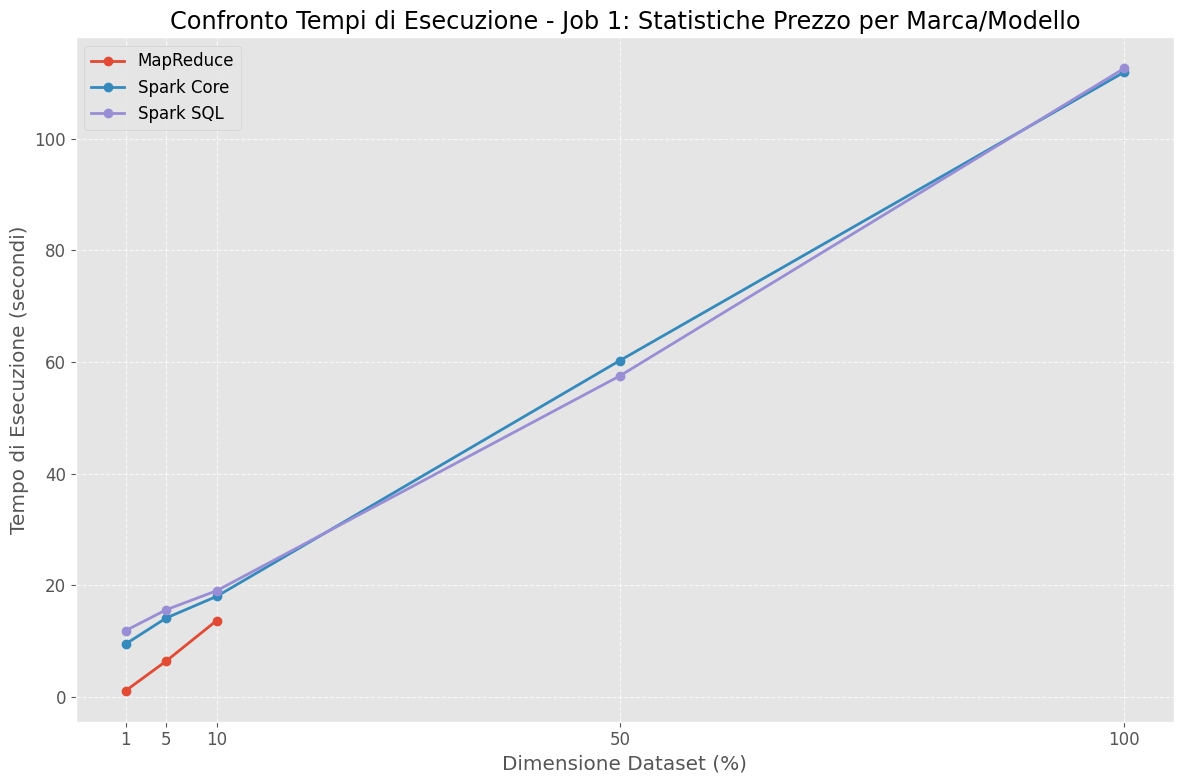

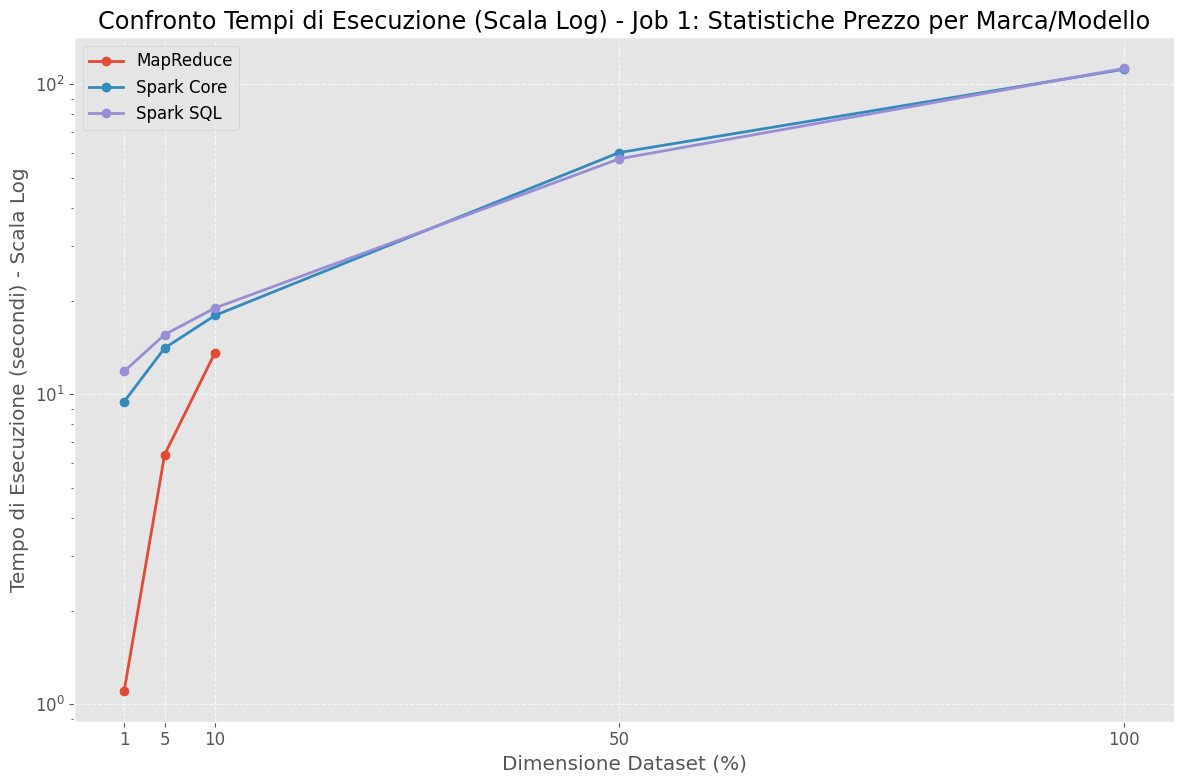

In [21]:
# Filtriamo i dati per Job 1
job1_df = comparison_df[comparison_df['job'] == 'job1'].sort_values('dataset_size_display')

# Creiamo un grafico che confronta i tempi di esecuzione per Job 1
plt.figure(figsize=(12, 8))
for engine, group in job1_df.groupby('engine_display'):
    plt.plot(group['dataset_size_display'], group['time_sec'], marker='o', linewidth=2, label=engine)

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Tempo di Esecuzione (secondi)')
plt.title('Confronto Tempi di Esecuzione - Job 1: Statistiche Prezzo per Marca/Modello')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# Utilizziamo solo valori non-NaN per gli xticks
valid_ticks = sorted(job1_df['dataset_size_display'].dropna().unique())
plt.xticks(valid_ticks)
plt.tight_layout()
plt.show()

# Creiamo anche un grafico logaritmico per visualizzare meglio le differenze
plt.figure(figsize=(12, 8))
for engine, group in job1_df.groupby('engine_display'):
    plt.plot(group['dataset_size_display'], group['time_sec'], marker='o', linewidth=2, label=engine)

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Tempo di Esecuzione (secondi) - Scala Log')
plt.title('Confronto Tempi di Esecuzione (Scala Log) - Job 1: Statistiche Prezzo per Marca/Modello')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(valid_ticks)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 5.3 Confronto dei tempi di esecuzione per Job 2

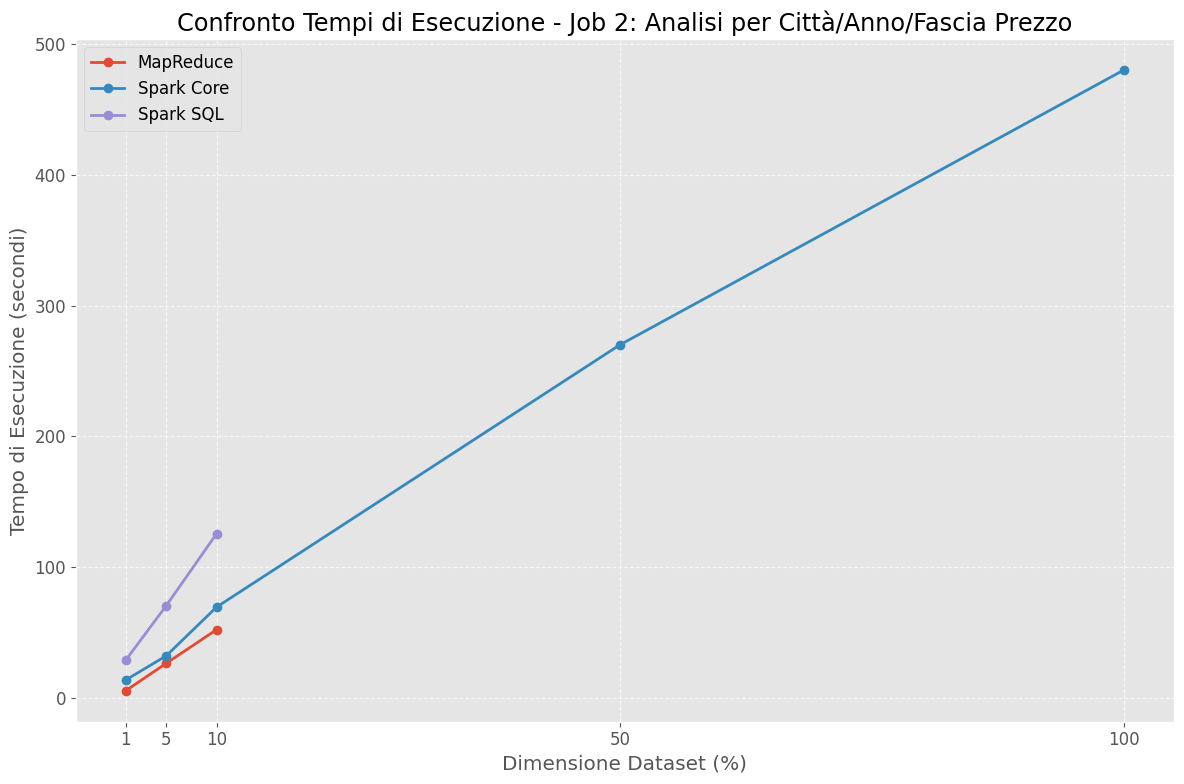

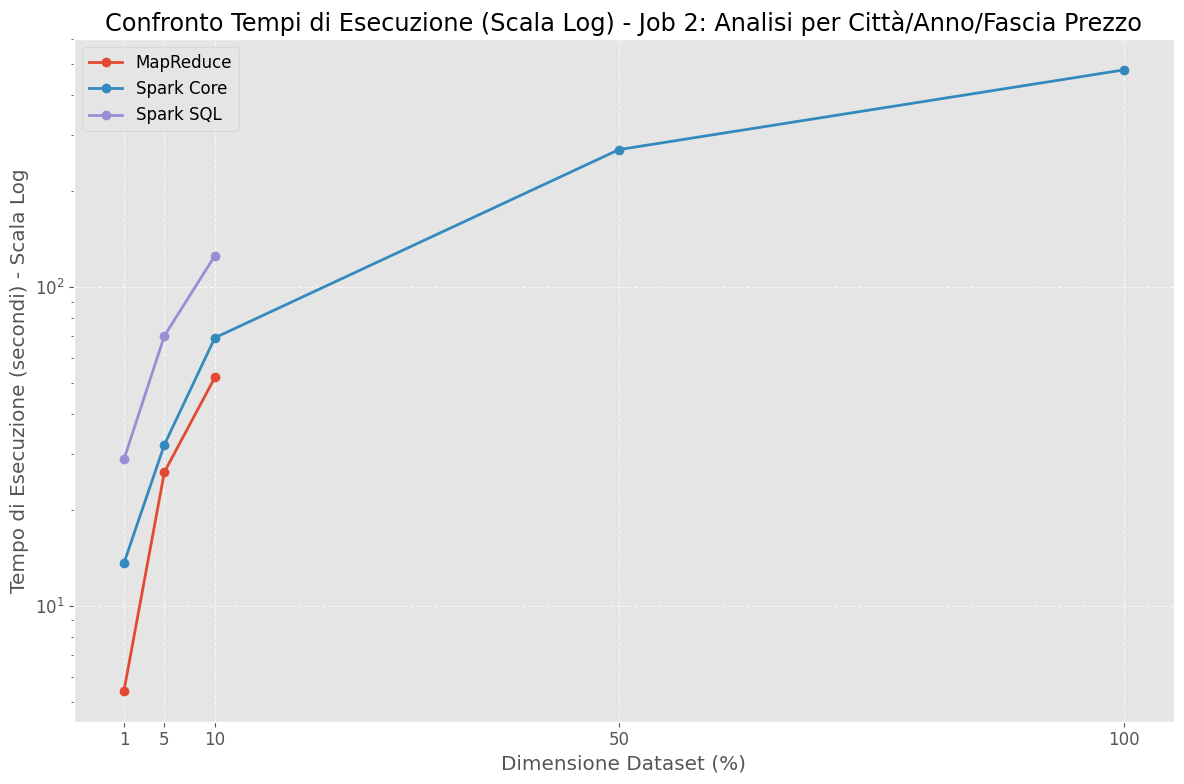

In [20]:
# Filtriamo i dati per Job 2
job2_df = comparison_df[comparison_df['job'] == 'job2'].sort_values('dataset_size_display')

# Creiamo un grafico che confronta i tempi di esecuzione per Job 2
plt.figure(figsize=(12, 8))
for engine, group in job2_df.groupby('engine_display'):
    plt.plot(group['dataset_size_display'], group['time_sec'], marker='o', linewidth=2, label=engine)

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Tempo di Esecuzione (secondi)')
plt.title('Confronto Tempi di Esecuzione - Job 2: Analisi per Città/Anno/Fascia Prezzo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
# Utilizziamo solo valori non-NaN per gli xticks
valid_ticks = sorted(job2_df['dataset_size_display'].dropna().unique())
plt.xticks(valid_ticks)
plt.tight_layout()
plt.show()

# Creiamo anche un grafico logaritmico per questo job
plt.figure(figsize=(12, 8))
for engine, group in job2_df.groupby('engine_display'):
    plt.plot(group['dataset_size_display'], group['time_sec'], marker='o', linewidth=2, label=engine)

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Tempo di Esecuzione (secondi) - Scala Log')
plt.title('Confronto Tempi di Esecuzione (Scala Log) - Job 2: Analisi per Città/Anno/Fascia Prezzo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(valid_ticks)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 5.4 Confronto della capacità di elaborazione (record/sec)

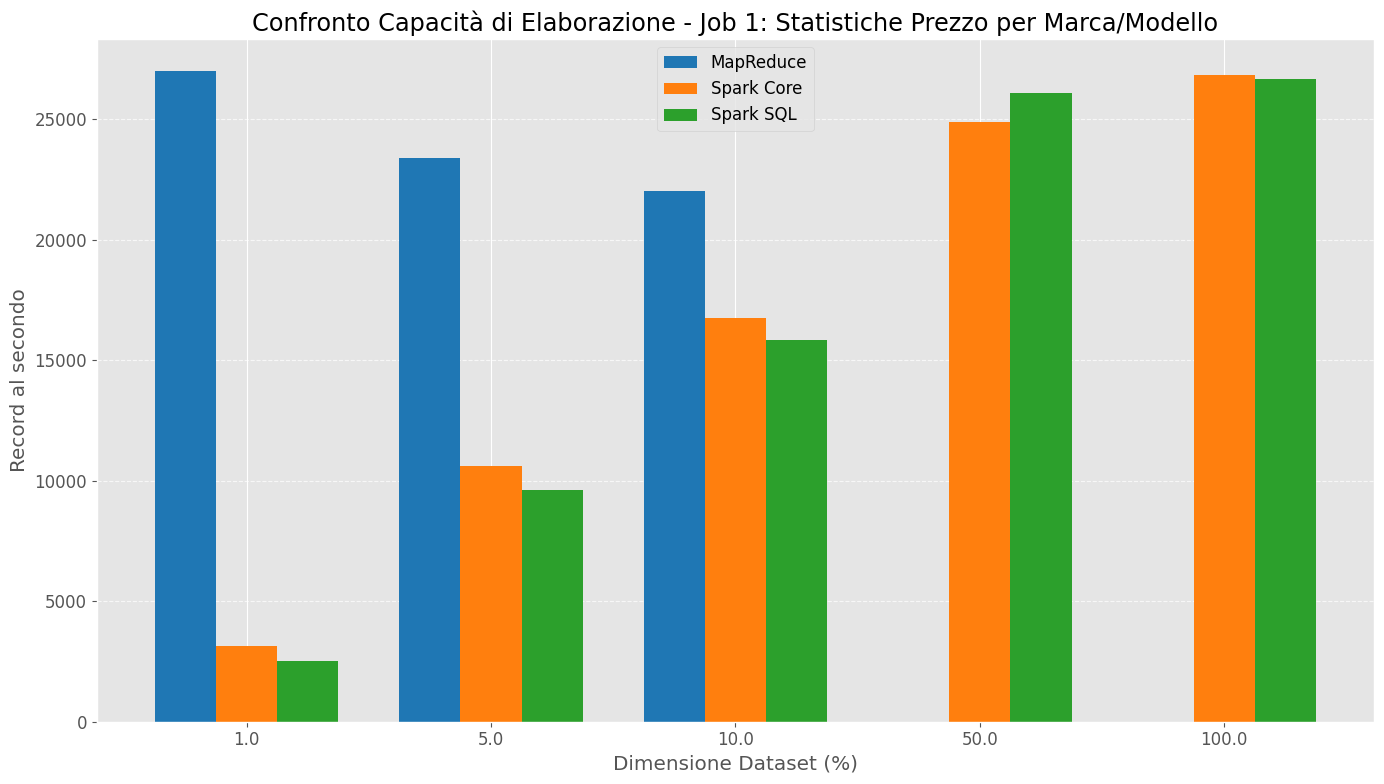

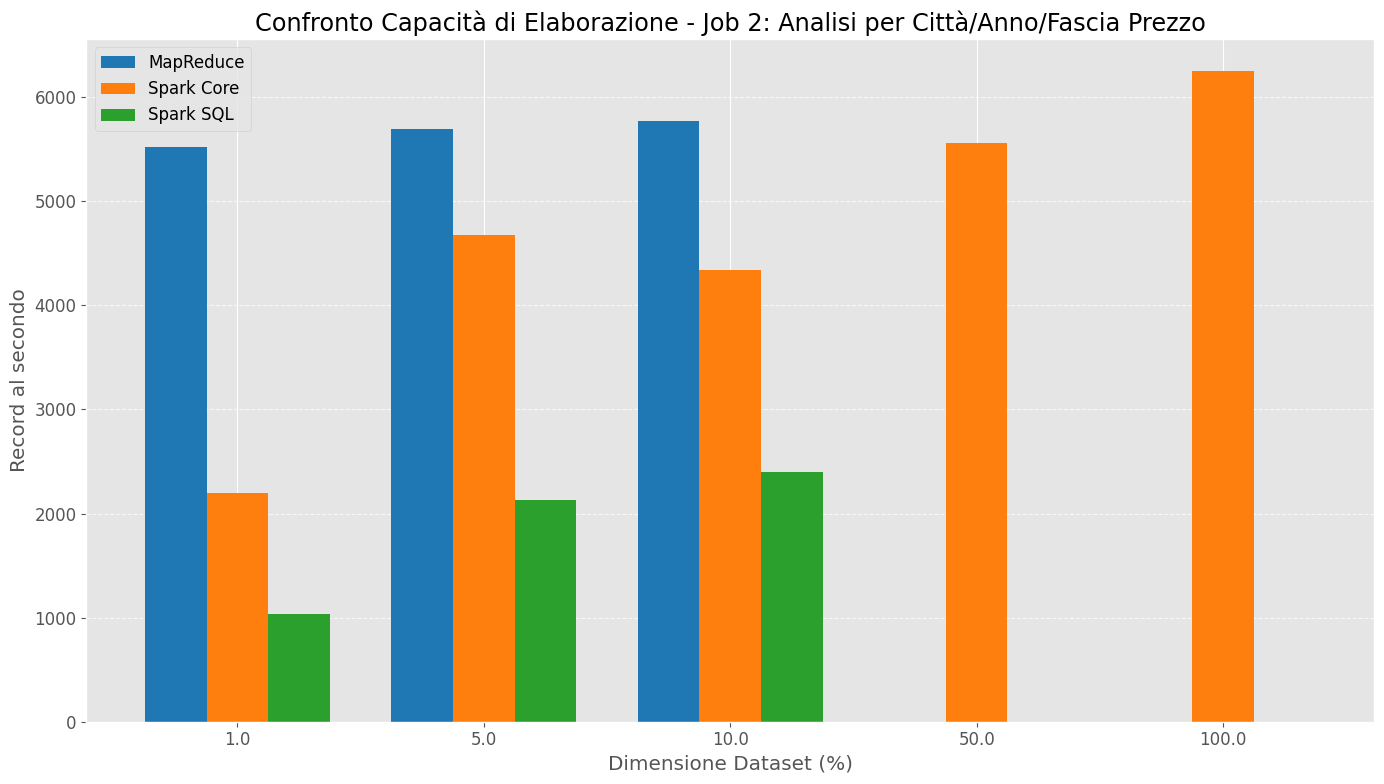

In [19]:
# Creiamo un grafico a barre per confrontare le capacità di elaborazione per Job 1
plt.figure(figsize=(14, 8))
sizes = sorted(job1_df['dataset_size_display'].dropna().unique())

# Impostazioni del grafico a barre
bar_width = 0.25
index = np.arange(len(sizes))
colors = plt.cm.tab10(np.arange(10))

i = 0
for engine, engine_data in job1_df.groupby('engine_display'):
    # Prepara i valori di throughput per ogni dimensione del dataset
    throughput_values = []
    for size in sizes:
        size_data = engine_data[engine_data['dataset_size_display'] == size]
        throughput_values.append(size_data['records_per_sec'].values[0] if not size_data.empty else 0)
    
    plt.bar(index + i*bar_width, throughput_values, bar_width, label=engine, color=colors[i % len(colors)])
    i += 1

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Record al secondo')
plt.title('Confronto Capacità di Elaborazione - Job 1: Statistiche Prezzo per Marca/Modello')
plt.xticks(index + bar_width, sizes)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Grafico a barre per job 2
plt.figure(figsize=(14, 8))
sizes = sorted(job2_df['dataset_size_display'].dropna().unique())

index = np.arange(len(sizes))

i = 0
for engine, engine_data in job2_df.groupby('engine_display'):
    throughput_values = []
    for size in sizes:
        size_data = engine_data[engine_data['dataset_size_display'] == size]
        throughput_values.append(size_data['records_per_sec'].values[0] if not size_data.empty else 0)
    
    plt.bar(index + i*bar_width, throughput_values, bar_width, label=engine, color=colors[i % len(colors)])
    i += 1

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Record al secondo')
plt.title('Confronto Capacità di Elaborazione - Job 2: Analisi per Città/Anno/Fascia Prezzo')
plt.xticks(index + bar_width, sizes)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 5.5 Analisi dello speedup in funzione della dimensione dei dati

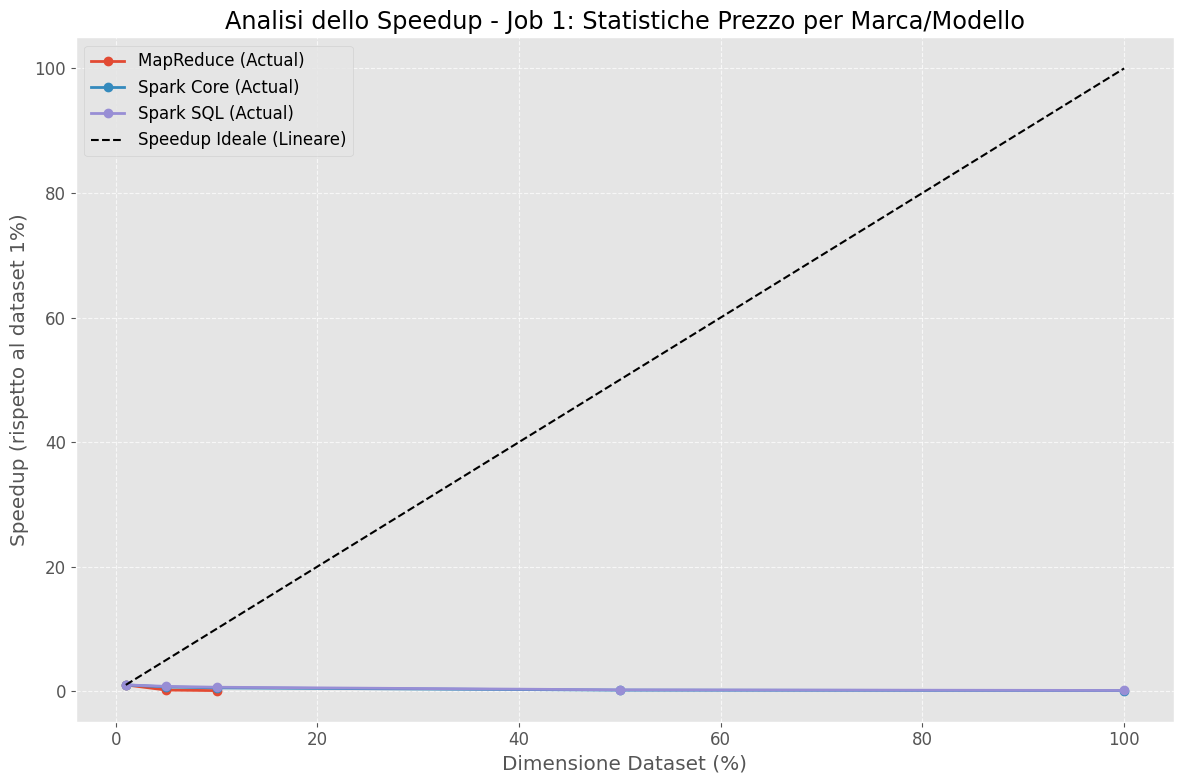

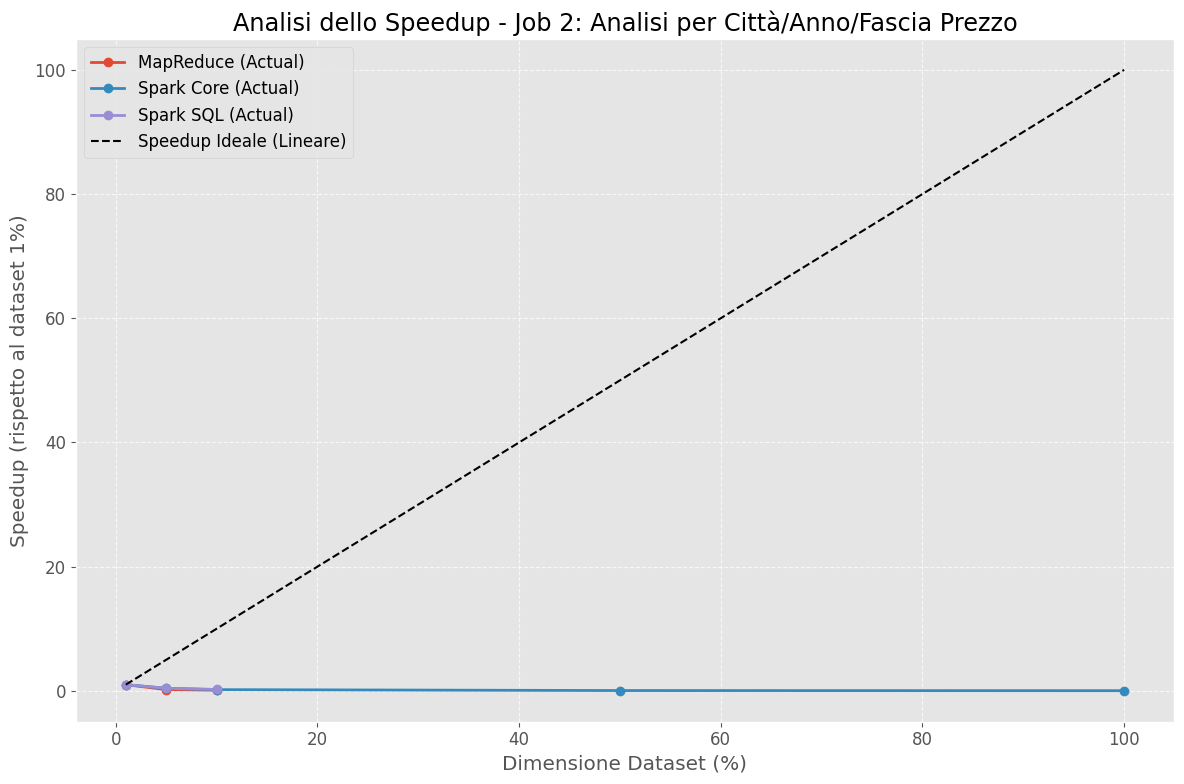

In [18]:
# Calcoliamo lo speedup per ogni dimensione di dataset rispetto alla dimensione più piccola
def calculate_speedup(df):
    result = pd.DataFrame()
    for engine, group in df.groupby(['job', 'engine_display']):
        job, engine_name = engine
        # Ordina per dimensione del dataset
        group = group.sort_values('dataset_size_display')
        if len(group) > 0 and not group['time_sec'].isna().all():
            # Tempo di esecuzione per il dataset più piccolo
            base_time = group['time_sec'].iloc[0]
            # Calcola speedup
            group['theoretical_speedup'] = group['dataset_size_display'] / group['dataset_size_display'].iloc[0]
            group['actual_speedup'] = base_time / group['time_sec']
            result = pd.concat([result, group])
    return result

speedup_df = calculate_speedup(comparison_df)

# Plot per Job 1
job1_speedup = speedup_df[speedup_df['job'] == 'job1']
plt.figure(figsize=(12, 8))

for engine, group in job1_speedup.groupby('engine_display'):
    plt.plot(group['dataset_size_display'], group['actual_speedup'], marker='o', linewidth=2, label=f"{engine} (Actual)")

# Aggiungi la linea dello speedup teorico (lineare)
ideal_sizes = sorted(job1_speedup['dataset_size_display'].dropna().unique())
if len(ideal_sizes) > 0:
    ideal_speedup = [sz / ideal_sizes[0] for sz in ideal_sizes]
    plt.plot(ideal_sizes, ideal_speedup, 'k--', label='Speedup Ideale (Lineare)')

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Speedup (rispetto al dataset 1%)')
plt.title('Analisi dello Speedup - Job 1: Statistiche Prezzo per Marca/Modello')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Plot per Job 2
job2_speedup = speedup_df[speedup_df['job'] == 'job2']
plt.figure(figsize=(12, 8))

for engine, group in job2_speedup.groupby('engine_display'):
    plt.plot(group['dataset_size_display'], group['actual_speedup'], marker='o', linewidth=2, label=f"{engine} (Actual)")

# Aggiungi la linea dello speedup teorico (lineare)
ideal_sizes = sorted(job2_speedup['dataset_size_display'].dropna().unique())
if len(ideal_sizes) > 0:
    ideal_speedup = [sz / ideal_sizes[0] for sz in ideal_sizes]
    plt.plot(ideal_sizes, ideal_speedup, 'k--', label='Speedup Ideale (Lineare)')

plt.xlabel('Dimensione Dataset (%)')
plt.ylabel('Speedup (rispetto al dataset 1%)')
plt.title('Analisi dello Speedup - Job 2: Analisi per Città/Anno/Fascia Prezzo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### 5.6 Tabella riassuntiva delle prestazioni

In [17]:
# Creiamo una tabella riassuntiva che confronta le prestazioni per i dataset più grandi
# Usiamo dataset_size_display invece di dataset_size_pct per catturare tutti i record
summary_100pct = comparison_df[comparison_df['dataset_size_display'] >= 50].copy()

# Pivot table per facilitare il confronto
summary_pivot = pd.pivot_table(
    summary_100pct,
    values=['time_sec', 'records_per_sec', 'mb_per_sec'],
    index=['job', 'dataset_size_display'],
    columns='engine_display',
    aggfunc='mean'
)

# Mostra la tabella riassuntiva
summary_pivot

mb_per_sec             records_per_sec  \
engine_display             Spark Core   Spark SQL      Spark Core   
job  dataset_size_display                                           
job1 50.0                  149.162131  156.285103    24903.332066   
     100.0                 160.687494  159.729953    26815.570827   
job2 50.0                   33.285969         NaN     5557.251878   
     100.0                  37.437774         NaN     6247.625391   

                                           time_sec              
engine_display                Spark SQL  Spark Core   Spark SQL  
job  dataset_size_display                                        
job1 50.0                  26092.546480   60.253905   57.507725  
     100.0                 26655.776151  111.914716  112.585617  
job2 50.0                           NaN  270.011695         NaN  
     100.0                          NaN  480.351624         NaN

## 6. Conclusioni e Discussione

### 6.1 Riepilogo dei Risultati

In questo studio abbiamo confrontato le prestazioni di tre diverse implementazioni (MapReduce, Spark Core e Spark SQL) su due differenti job di analisi dei dati sulle auto usate.

**Job 1 (Statistiche sui prezzi per marca e modello)**:
- Job relativamente semplice che richiede aggregazioni di base e calcolo di statistiche
- MapReduce ha mostrato prestazioni eccellenti per dataset di piccole dimensioni, ma un rapido degrado all'aumentare della dimensione del dataset
- Spark Core e Spark SQL hanno mostrato prestazioni simili tra loro per questo job
- Per dataset grandi (≥50%), Spark ha mostrato un vantaggio significativo rispetto a MapReduce

**Job 2 (Analisi per città, anno e fascia di prezzo)**:
- Job più complesso con maggiore elaborazione dei dati, specialmente nella tokenizzazione e analisi delle parole
- MapReduce ha mostrato prestazioni superiori a Spark per dataset piccoli
- Spark Core ha superato Spark SQL in termini di prestazioni grazie al controllo più diretto sull'elaborazione
- All'aumentare della dimensione del dataset, il divario di prestazioni tra le tecnologie si è ridotto

### 6.2 Efficienza di Scalabilità

- **MapReduce** ha mostrato una scalabilità sub-lineare per il Job 2, con un tempo di esecuzione che aumenta meno che proporzionalmente rispetto alla dimensione dei dati
- **Spark Core** ha mostrato la migliore scalabilità per entrambi i job, indicando una buona gestione della memoria e dell'elaborazione in-memory
- **Spark SQL** ha mostrato buone prestazioni per il Job 1, ma una scalabilità inferiore per il Job 2 più complesso

### 6.3 Confronto Architetturale

- **Semplicità implementativa**: MapReduce è più semplice da implementare per operazioni di base, ma richiede più codice personalizzato per operazioni complesse
- **Espressività**: Spark offre un'API più espressiva che permette implementazioni più concise e leggibili
- **Gestione della memoria**: Spark beneficia dell'elaborazione in-memory, particolarmente evidente per operazioni iterative o complesse
- **Overhead di avvio**: Spark mostra un overhead di inizializzazione maggiore, che impatta le prestazioni per dataset piccoli

### 6.4 Considerazioni per la Scelta della Tecnologia

- **Per dataset di piccole dimensioni**: MapReduce può essere sufficiente e talvolta più veloce
- **Per dataset di medie/grandi dimensioni**: Spark offre migliori prestazioni e scalabilità
- **Per query analitiche**: Spark SQL fornisce un'espressività superiore e ottimizzazioni automatiche
- **Per job con trasformazioni complesse**: Spark Core offre un buon compromesso tra controllo e prestazioni

### 6.5 Possibili Ottimizzazioni Future

1. **Partizionamento ottimizzato**: Testare diverse strategie di partizionamento per migliorare la distribuzione del carico
2. **Ottimizzazione della memoria**: Regolare i parametri di memoria di Spark per carichi di lavoro specifici
3. **Pre-elaborazione dei dati**: Valutare formati colonnari come Parquet per migliorare l'efficienza di lettura
4. **Ottimizzazione delle UDF**: Convertire UDF Python costose in funzioni native Spark quando possibile

## 7. Repository GitHub

Il codice completo del progetto è disponibile su GitHub al seguente indirizzo:

[https://github.com/lukebo01/used-cars-big-data-analysis](https://github.com/lukebo01/used-cars-big-data-analysis)

Il repository include:
- Codice sorgente per le implementazioni MapReduce e Spark
- Script per il preprocessing dei dati
- Script per l'esecuzione dei benchmark
- Notebook per l'analisi dei risultati
- Documentazione dettagliata